## Dataset Loading and Model Training

In [1]:
# Initializations
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Loading the data

housing = fetch_california_housing()

print(f"This is the target: {housing.target_names[0]}")
print(f"These are the features: {str(housing.feature_names)[1:-1]}")

This is the target: MedHouseVal
These are the features: 'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'


In [2]:
# Setting up training 

X, y = housing.data, housing.target

# Take half to speed up training
half = housing.data.shape[0]//2
X = X[:half]
y = y[:half]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



# 3 base models to complicate things
def make_base_models():
    model1 = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=0, n_jobs=-1, eval_metric="rmse",
    )
    model2 = xgb.XGBRegressor(
        n_estimators=700, learning_rate=0.02, max_depth=4,
        subsample=0.7, colsample_bytree=0.6,
        reg_alpha=0.5, reg_lambda=2.0, min_child_weight=5,
        random_state=1, n_jobs=-1, eval_metric="rmse",
    )
    model3 = xgb.XGBRegressor(
        n_estimators=600, learning_rate=0.03, max_depth=5,
        subsample=0.9, colsample_bytree=0.75,
        reg_alpha=0.2, reg_lambda=1.5,
        booster="dart", rate_drop=0.1,
        random_state=2, n_jobs=-1, eval_metric="rmse",
    )
    return [model1, model2, model3]

model_names = ["XGB-1-deep", "XGB-2-shallow", "XGB-3-DART"]

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"These were the stats {name} rmse {rmse}, mae {mae}, r2 {r2}")
    return rmse, mae, r2


base_models = make_base_models()
for name, model in zip(model_names, base_models):
    print(f"Training...{name}")
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)], verbose=False)

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros((X_train.shape[0], len(base_models)))

print(f"Generating fold OOF predictions for meta-learner")
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr        = y_train[tr_idx]

    fold_models = make_base_models()   
    for col, (name, m) in enumerate(zip(model_names, fold_models)):
        m.fit(X_tr, y_tr, verbose=False)
        oof_preds[val_idx, col] = m.predict(X_val)

    print(f"Fold {fold} complete")

meta_X_train = oof_preds                                                  
meta_X_test  = np.column_stack([m.predict(X_test)               
                                 for m in base_models])


# Train XGBoost meta-learner to further complicate
meta_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,           
    subsample=0.8,
    colsample_bytree=1.0, 
    reg_alpha=0.1,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="rmse",
)
meta_model.fit(
    meta_X_train, y_train,
    eval_set=[(meta_X_test, y_test)],
    verbose=False,
)

print("Test-set performance")
stack_preds = meta_model.predict(meta_X_test)
evaluate("Ensemble (XGB meta-learner / stacking)", y_test, stack_preds)

def stacked_predict(X):
    if isinstance(X, pd.DataFrame):
        X = X.values
    meta_input = np.column_stack([m.predict(X) for m in base_models])
    return meta_model.predict(meta_input)

Training...XGB-1-deep
Training...XGB-2-shallow
Training...XGB-3-DART
Generating fold OOF predictions for meta-learner
Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete
Test-set performance
These were the stats Ensemble (XGB meta-learner / stacking) rmse 0.4266782568425974, mae 0.26882856617744577, r2 0.8711946067518791


## Local Methods

### LIME

Intercept 1.6357480075684345
Prediction_local [3.94517744]
Right: 4.972824


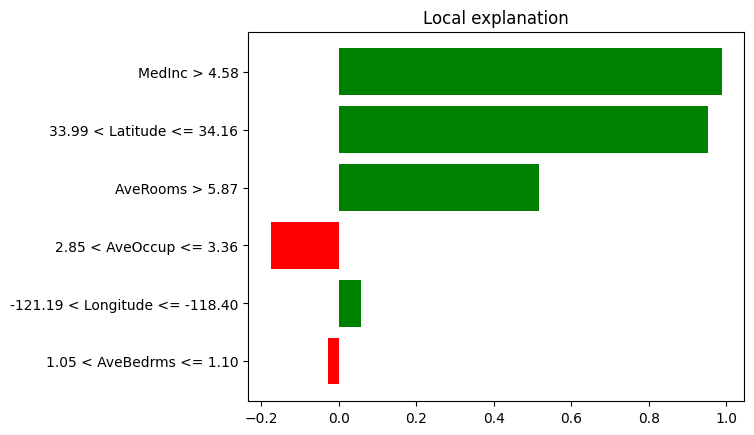

In [3]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import pandas as pd

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=housing.feature_names,
    verbose=True,
    mode='regression'
)

exp = explainer.explain_instance(X_test[10], stacked_predict, num_features=6)
fig = exp.as_pyplot_figure()
plt.show()

### SHAP


100%|██████████| 100/100 [00:16<00:00,  6.16it/s]


ValueError: too many values to unpack (expected 1, got 100)

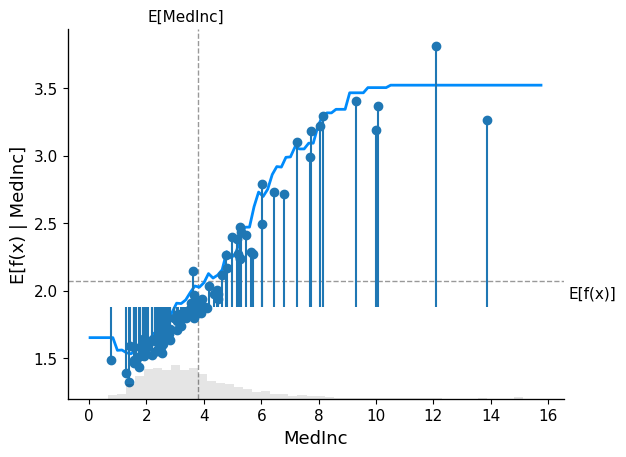

In [6]:
import shap
import pandas as pd
import numpy as np

X_test_df = pd.DataFrame(X_test, columns=housing.feature_names) 


explainer_xgb = shap.KernelExplainer(stacked_predict, shap.sample(X_test_df, 100))
shap_values_xgb = explainer_xgb(X_test_df.iloc[:100])


fig, ax = shap.partial_dependence_plot(
    "MedInc",
    stacked_predict,
    X_test_df,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
    shap_values=shap_values_xgb
)

### Dice

In [ ]:
import dice_ml

d = dice_ml.Data(dataframe=X_train, continuous_features=housing.feature_names, outcome_name='price')
m = dice_ml.Model(model=stacked_predict, backend='sklearn')
exp = dice_ml.Dice(d, m, method='random')

e = exp.generate_counterfactuals(X_test_df.iloc[[10]], total_CFs=3, desired_range=[3.0, 4.0])
e.visualize_as_dataframe()